# Node-Level Inflow Prediction From GMEL Embeddings

This notebook explores a simpler, node-level alternative to the `GMEL -> GBRT` edge-flow pipeline.

Instead of predicting one OD flow `(src, dst) -> count`, we predict the **total inflow of a destination node** from its GMEL destination embedding.

Workflow:
1. Load the trained GMEL checkpoint and compute destination embeddings.
2. Build node-level inflow targets by aggregating all edges across train/valid/test.
3. Split nodes into held-out train/valid/test sets.
4. Train a small differentiable MLP regressor on destination embeddings.
5. Report validation/test results and visualize predictions.

This gives us a node prediction task that is more natural for node-level counterfactual methods.

## 1. Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import utils
from model import MyModel

warnings.filterwarnings(
    "ignore",
    message="Feature table contains NaN. 0 is used to fill these NaNs"
)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cwd:", os.getcwd())

torch: 2.3.0
cuda available: True
cwd: c:\Users\qshah\Documents\Spring 2026\GMEL\code


## 2. Config

In [15]:
YEAR = 2015
NUM_HIDDEN_LAYERS = 1
EMBEDDING_SIZE = 128
MULTITASK_WEIGHTS = (0.5, 0.25, 0.25)

# Keep this on CPU unless utils.build_graph_from_matrix is updated for CUDA graph construction.
DEVICE = "cpu"
SEED = 42

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 128
MAX_EPOCHS = 500
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 100

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device(DEVICE)

assert abs(TRAIN_RATIO + VALID_RATIO + TEST_RATIO - 1.0) < 1e-8
print("Using device:", device)
print("GMEL config:", YEAR, NUM_HIDDEN_LAYERS, EMBEDDING_SIZE, MULTITASK_WEIGHTS)

Using device: cpu
GMEL config: 2015 1 128 (0.5, 0.25, 0.25)


## 3. Load Data and GMEL Checkpoint

In [16]:
data = utils.load_dataset(year=YEAR)

node_feats = data["node_feats"].astype(np.float32)
ct_adj = data["ct_adjacency_withweight"]
num_nodes = data["num_nodes"]

g = utils.build_graph_from_matrix(ct_adj, node_feats, device=DEVICE).to(device)

ckpt_path = Path(
    f"./models/model_state_layers{NUM_HIDDEN_LAYERS}_"
    f"emb{EMBEDDING_SIZE}_multitask{MULTITASK_WEIGHTS}.pth"
)
assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"

gmel_model = MyModel(
    g=g,
    num_nodes=num_nodes,
    in_dim=node_feats.shape[1],
    h_dim=EMBEDDING_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    device=str(device),
    reg_param=0,
).to(device)

ckpt = torch.load(ckpt_path, map_location=device)
gmel_model.load_state_dict(ckpt["state_dict"])
gmel_model.eval()

print("num_nodes:", num_nodes)
print("node_feats shape:", node_feats.shape)
print("checkpoint:", ckpt_path)
print("best validation RMSE from GMEL training:", round(float(ckpt.get("rmse", np.nan)), 4))

num_nodes: 2168
node_feats shape: (2168, 65)
checkpoint: models\model_state_layers1_emb128_multitask(0.5, 0.25, 0.25).pth
best validation RMSE from GMEL training: 7.2047


## 4. Build Node-Level Inflow Targets

In [17]:
all_edges = np.vstack([data["train"], data["valid"], data["test"]])

total_inflow = np.zeros(num_nodes, dtype=np.float32)
train_inflow = np.asarray(data["train_inflow"], dtype=np.float32).reshape(-1)
np.add.at(total_inflow, all_edges[:, 1].astype(int), all_edges[:, 2].astype(np.float32))

target_df = pd.DataFrame({
    "node_id": np.arange(num_nodes),
    "train_inflow": train_inflow,
    "total_inflow": total_inflow,
})

display(target_df.head())
print("Nodes with zero total inflow:", int((total_inflow == 0).sum()))
print("Total inflow range:", float(total_inflow.min()), "to", float(total_inflow.max()))
print("Median total inflow:", float(np.median(total_inflow)))

,node_id,train_inflow,total_inflow
0,0,81.0,125.0
1,1,136.0,268.0
2,2,441.0,717.0
3,3,34.0,62.0
4,4,1128.0,1888.0


Nodes with zero total inflow: 20
Total inflow range: 0.0 to 50330.0
Median total inflow: 410.0


## 5. Compute Destination Embeddings and a GMEL-Head Baseline

In [18]:
with torch.no_grad():
    src_emb = gmel_model(g).detach().cpu().numpy()
    dst_emb = gmel_model.forward2(g).detach().cpu().numpy()
    inflow_head_pred = gmel_model.predict_inflow(
        torch.from_numpy(dst_emb).float().to(device),
        torch.arange(num_nodes, device=device)
    ).detach().cpu().numpy().reshape(-1)

inflow_head_pred = np.clip(utils.scale_back(torch.from_numpy(inflow_head_pred)).numpy().reshape(-1), 0, None)

print("src_emb shape:", src_emb.shape)
print("dst_emb shape:", dst_emb.shape)
print("GMEL inflow-head prediction range:", float(inflow_head_pred.min()), "to", float(inflow_head_pred.max()))

src_emb shape: (2168, 128)
dst_emb shape: (2168, 128)
GMEL inflow-head prediction range: 0.00304515496827662 to 27144.2421875


## 6. Create a Held-Out Node Split

In [19]:
rng = np.random.default_rng(SEED)
node_ids = np.arange(num_nodes)
perm = rng.permutation(node_ids)

n_train = int(num_nodes * TRAIN_RATIO)
n_valid = int(num_nodes * VALID_RATIO)

idx_train = np.sort(perm[:n_train])
idx_valid = np.sort(perm[n_train:n_train + n_valid])
idx_test = np.sort(perm[n_train + n_valid:])

print("train / valid / test nodes:", len(idx_train), len(idx_valid), len(idx_test))
print("positive total inflow rates:")
print("  train:", round(float((total_inflow[idx_train] > 0).mean()), 3))
print("  valid:", round(float((total_inflow[idx_valid] > 0).mean()), 3))
print("  test :", round(float((total_inflow[idx_test] > 0).mean()), 3))

train / valid / test nodes: 1517 325 326
positive total inflow rates:
  train: 0.991
  valid: 0.991
  test : 0.991


## 7. Train a Differentiable MLP Regressor

In [20]:
def sqrt_scale(y):
    return np.sqrt(y.astype(np.float32))

def sqrt_unscale(y_scaled):
    return np.clip(y_scaled, 0, None) ** 2

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def mape_positive(y_true, y_pred):
    mask = y_true > 0
    if not mask.any():
        return float("nan")
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]))

class InflowMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

X = torch.from_numpy(dst_emb).float()
y = torch.from_numpy(sqrt_scale(total_inflow)).float().view(-1, 1)

train_ds = TensorDataset(X[idx_train], y[idx_train])
valid_ds = TensorDataset(X[idx_valid], y[idx_valid])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

mlp = InflowMLP(dst_emb.shape[1]).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

best_state = None
best_valid_rmse = float("inf")
best_epoch = -1
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    mlp.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = mlp(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    mlp.eval()
    with torch.no_grad():
        valid_pred_scaled = mlp(X[idx_valid].to(device)).cpu().numpy().reshape(-1)
        train_pred_scaled = mlp(X[idx_train].to(device)).cpu().numpy().reshape(-1)

    valid_pred = sqrt_unscale(valid_pred_scaled)
    train_pred = sqrt_unscale(train_pred_scaled)
    valid_true = total_inflow[idx_valid]
    train_true = total_inflow[idx_train]

    train_rmse = rmse(train_true, train_pred)
    valid_rmse = rmse(valid_true, valid_pred)
    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "train_rmse": train_rmse,
        "valid_rmse": valid_rmse,
    })

    if valid_rmse < best_valid_rmse:
        best_valid_rmse = valid_rmse
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 25 == 0:
        print(f"epoch {epoch:03d} | train RMSE {train_rmse:.3f} | valid RMSE {valid_rmse:.3f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

mlp.load_state_dict(best_state)
print(f"Best validation RMSE: {best_valid_rmse:.3f} at epoch {best_epoch}")

epoch 001 | train RMSE 4354.933 | valid RMSE 3393.427
epoch 025 | train RMSE 601.114 | valid RMSE 474.122
epoch 050 | train RMSE 565.195 | valid RMSE 466.240
epoch 075 | train RMSE 534.995 | valid RMSE 466.358
epoch 100 | train RMSE 522.874 | valid RMSE 471.732
Early stopping at epoch 118.
Best validation RMSE: 449.768 at epoch 18


## 8. Test Results

In [21]:
def evaluate_predictions(y_true, y_pred, name):
    return {
        "split": name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MAPE_pos": mape_positive(y_true, y_pred),
    }

with torch.no_grad():
    pred_scaled_all = mlp(X.to(device)).cpu().numpy().reshape(-1)
pred_all = sqrt_unscale(pred_scaled_all)

results = pd.DataFrame([
    evaluate_predictions(total_inflow[idx_train], pred_all[idx_train], "train"),
    evaluate_predictions(total_inflow[idx_valid], pred_all[idx_valid], "valid"),
    evaluate_predictions(total_inflow[idx_test],  pred_all[idx_test],  "test"),
])

display(results)

gmel_head_results = pd.DataFrame([
    evaluate_predictions(train_inflow[idx_train], inflow_head_pred[idx_train], "train"),
    evaluate_predictions(train_inflow[idx_valid], inflow_head_pred[idx_valid], "valid"),
    evaluate_predictions(train_inflow[idx_test],  inflow_head_pred[idx_test],  "test"),
])

print("Reference only: GMEL's built-in inflow head against TRAIN inflow target")
display(gmel_head_results)

,split,RMSE,MAE,MAPE_pos
0,train,588.093750,237.202194,5.183684
1,valid,449.767609,235.593201,1.364839
2,test,293.837006,185.412094,1.197762


Reference only: GMEL's built-in inflow head against TRAIN inflow target


,split,RMSE,MAE,MAPE_pos
0,train,350.288239,128.601486,9.233951
1,valid,226.275528,126.918831,1.702843
2,test,159.172821,105.976601,1.869316


## 9. Visual Checks

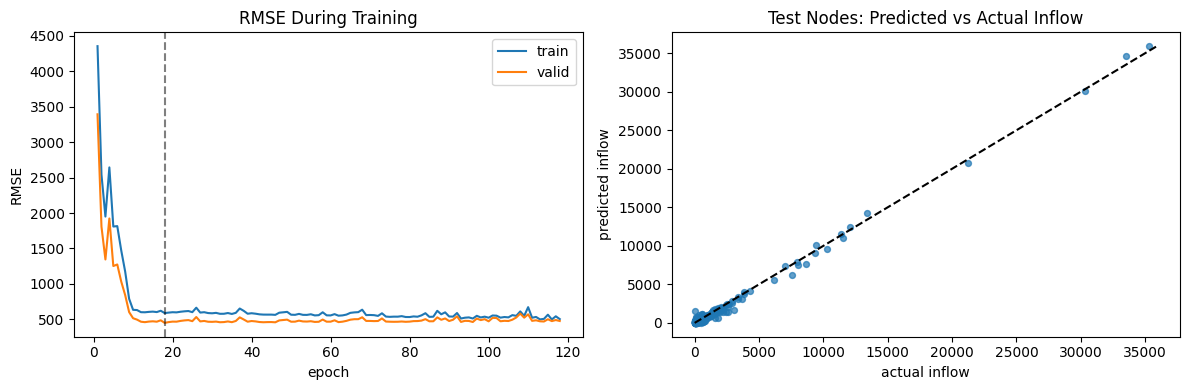

In [22]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_rmse"], label="train")
axes[0].plot(history_df["epoch"], history_df["valid_rmse"], label="valid")
axes[0].axvline(best_epoch, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("RMSE During Training")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].scatter(total_inflow[idx_test], pred_all[idx_test], s=18, alpha=0.7)
lo = float(min(total_inflow[idx_test].min(), pred_all[idx_test].min()))
hi = float(max(total_inflow[idx_test].max(), pred_all[idx_test].max()))
axes[1].plot([lo, hi], [lo, hi], linestyle="--", color="black")
axes[1].set_title("Test Nodes: Predicted vs Actual Inflow")
axes[1].set_xlabel("actual inflow")
axes[1].set_ylabel("predicted inflow")

plt.tight_layout()
plt.show()

In [25]:
test_df = pd.DataFrame({
    "node_id": idx_test,
    "actual_total_inflow": total_inflow[idx_test],
    "pred_total_inflow": pred_all[idx_test],
})
test_df["abs_error"] = np.abs(test_df["actual_total_inflow"] - test_df["pred_total_inflow"])

print("Worst test-node errors:")
display(test_df.sort_values("abs_error", ascending=True).head(50))

Worst test-node errors:


,node_id,actual_total_inflow,pred_total_inflow,abs_error
197,1296,119.0,118.781822,0.218178
33,279,9.0,6.995265,2.004735
85,564,396.0,398.045532,2.045532
155,1046,398.0,401.384247,3.384247
235,1530,116.0,112.144753,3.855247
9,76,2866.0,2861.939453,4.060547
257,1633,93.0,87.774544,5.225456
121,828,111.0,116.380394,5.380394
308,2015,196.0,201.519440,5.519440
105,732,808.0,813.581177,5.581177


## 10. Notes

- The new MLP is evaluated on a **held-out node split**, not the original edge split from the OD task.
- The target here is **total inflow per destination node**, aggregated across all OD records in train/valid/test.
- The GMEL inflow head shown above is only a reference baseline. It was originally trained against `train_inflow`, not the new held-out node task.
- If this node-level predictor looks promising, the next step is to discretize inflow into classes and use a node-level counterfactual explainer directly.